# **Global Vaccination Data Analysis**

##### **Project Type**    - EDA/Regression
##### **Contribution**    - Individual


# **Project Summary -**

This project analyzes global WHO immunization data spanning over 40 years and 190+ countries to understand the relationship between vaccination coverage and vaccine-preventable disease (VPD) incidence. Five WHO Immunization Data portal datasets were used: vaccination coverage by antigen, disease incidence rates, reported case counts, vaccine introduction status, and national vaccination schedules.

The analysis followed a structured pipeline: cleaning and standardizing country codes and years across all five tables, matching vaccines to the diseases they target (e.g. MCV1/MCV2 to measles, POL3/IPV to poliomyelitis), and merging coverage with incidence and case data at the country-disease-year level. This produced a analytical dataset of over 74,000 records linking vaccination effort directly to disease outcomes.

Exploratory data analysis followed the Univariate-Bivariate-Multivariate (UBM) framework, producing 15+ visualizations covering distributions of coverage and incidence, regional and disease-level comparisons, year-over-year trends, and correlation structure. Three hypotheses were tested: whether higher coverage is associated with lower incidence, whether incidence varies significantly by WHO region, and whether coverage levels differ significantly across disease types — all three were supported with statistically significant results.

For the predictive modeling stage, disease incidence rate was framed as a regression target, using vaccination coverage, year, disease type, and WHO region as predictors. Three models were built and compared: Linear Regression as a baseline, Random Forest Regressor, and Gradient Boosting Regressor, each evaluated with cross-validation and hyperparameter tuning via GridSearchCV/RandomizedSearchCV. Model performance was assessed using RMSE, MAE, and R² score, and feature importance was extracted from the tree-based models to explain which factors most influence disease incidence.

Key findings show a clear negative relationship between vaccination coverage and disease incidence, with substantial variation by WHO region and disease type — driven by differences in health infrastructure, vaccine introduction timelines, and reporting practices. The best-performing model was saved for deployment and validated with a reload-and-predict sanity check.

These insights support public health decision-making: identifying low-coverage, high-incidence regions for targeted resource allocation, prioritizing diseases where vaccination has underperformed relative to coverage levels, and providing a data-driven baseline for tracking progress toward global immunization targets such as 95% coverage by 2030.

Provide your GitHub Link here.

# **Problem Statement**

Analyze global vaccination data to understand trends in vaccination coverage, disease incidence, and effectiveness, in order to support public health strategy, disease prevention, resource allocation, and global health policy decisions.

**Questions answered in this notebook:**
- How do vaccination rates correlate with a decrease in disease incidence?
- Which regions have high disease incidence despite reasonable vaccination rates?
- Are there significant disparities in disease incidence across WHO regions?
- What percentage of the target population has been covered, by disease?
- Which diseases show the most significant reduction in cases relative to coverage?
- Can we predict disease incidence rate from vaccination coverage and related features?

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus.
3.   Each and every logic should have proper comments.
4. 15+ logical & meaningful charts following the **UBM Rule** (Univariate, Bivariate, Multivariate).
5. Multiple ML models compared with cross-validation and hyperparameter tuning.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


### Dataset Loading

In [2]:
# Load Datasets
# Upload these 5 files to the Colab session (or mount Google Drive) before running:
# coverage-data.xlsx, incidence-rate-data.xlsx, reported-cases-data.xlsx,
# vaccine-introduction-data.xlsx, vaccine-schedule-data.xlsx

coverage_raw = pd.read_excel('coverage-data.xlsx', sheet_name='Data')
incidence_raw = pd.read_excel('incidence-rate-data.xlsx', sheet_name='Data')
cases_raw = pd.read_excel('reported-cases-data.xlsx', sheet_name='Data')
intro_raw = pd.read_excel('vaccine-introduction-data.xlsx', sheet_name='Data')
schedule_raw = pd.read_excel('vaccine-schedule-data.xlsx', sheet_name='Data')

print("Coverage:", coverage_raw.shape)
print("Incidence:", incidence_raw.shape)
print("Cases:", cases_raw.shape)
print("Vaccine Introduction:", intro_raw.shape)
print("Vaccine Schedule:", schedule_raw.shape)


Coverage: (399859, 11)
Incidence: (84946, 8)
Cases: (84870, 7)
Vaccine Introduction: (138321, 6)
Vaccine Schedule: (8053, 12)


### Dataset First View

In [3]:
# Dataset First Look
coverage_raw.head()

,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52
3,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",OFFICIAL,Official coverage,NaN,NaN,90.52
4,COUNTRIES,ABW,Aruba,2023.0,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219.0,1008.0,82.69


In [4]:
incidence_raw.head()

,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3
3,COUNTRIES,ABW,Aruba,2023.0,MEASLES,Measles,"per 1,000,000 total population",NaN
4,COUNTRIES,ABW,Aruba,2023.0,MUMPS,Mumps,"per 1,000,000 total population",0.0


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
for name, df in [('Coverage', coverage_raw), ('Incidence', incidence_raw), ('Cases', cases_raw),
                  ('Vaccine Introduction', intro_raw), ('Vaccine Schedule', schedule_raw)]:
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

Coverage: 399859 rows, 11 columns
Incidence: 84946 rows, 8 columns
Cases: 84870 rows, 7 columns
Vaccine Introduction: 138321 rows, 6 columns
Vaccine Schedule: 8053 rows, 12 columns


### Dataset Information

In [6]:
# Dataset Info
coverage_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          399859 non-null  object 
 1   CODE                           399858 non-null  object 
 2   NAME                           398584 non-null  object 
 3   YEAR                           399858 non-null  float64
 4   ANTIGEN                        399858 non-null  object 
 5   ANTIGEN_DESCRIPTION            399858 non-null  object 
 6   COVERAGE_CATEGORY              399858 non-null  object 
 7   COVERAGE_CATEGORY_DESCRIPTION  399858 non-null  object 
 8   TARGET_NUMBER                  79030 non-null   float64
 9   DOSES                          79327 non-null   float64
 10  COVERAGE                       230477 non-null  float64
dtypes: float64(4), object(7)
memory usage: 33.6+ MB


In [7]:
incidence_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84946 entries, 0 to 84945
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GROUP                84946 non-null  object 
 1   CODE                 84945 non-null  object 
 2   NAME                 84945 non-null  object 
 3   YEAR                 84945 non-null  float64
 4   DISEASE              84945 non-null  object 
 5   DISEASE_DESCRIPTION  84945 non-null  object 
 6   DENOMINATOR          84945 non-null  object 
 7   INCIDENCE_RATE       61584 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.2+ MB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
for name, df in [('Coverage', coverage_raw), ('Incidence', incidence_raw), ('Cases', cases_raw),
                  ('Vaccine Introduction', intro_raw), ('Vaccine Schedule', schedule_raw)]:
    print(f"{name} duplicate rows: {df.duplicated().sum()}")

Coverage duplicate rows: 0
Incidence duplicate rows: 0
Cases duplicate rows: 0
Vaccine Introduction duplicate rows: 0
Vaccine Schedule duplicate rows: 0


#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
print("Coverage nulls:\n", coverage_raw.isnull().sum())
print("\nIncidence nulls:\n", incidence_raw.isnull().sum())

Coverage nulls:
 GROUP                                 0
CODE                                  1
NAME                               1275
YEAR                                  1
ANTIGEN                               1
ANTIGEN_DESCRIPTION                   1
COVERAGE_CATEGORY                     1
COVERAGE_CATEGORY_DESCRIPTION         1
TARGET_NUMBER                    320829
DOSES                            320532
COVERAGE                         169382
dtype: int64

Incidence nulls:
 GROUP                      0
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
DENOMINATOR                1
INCIDENCE_RATE         23362
dtype: int64


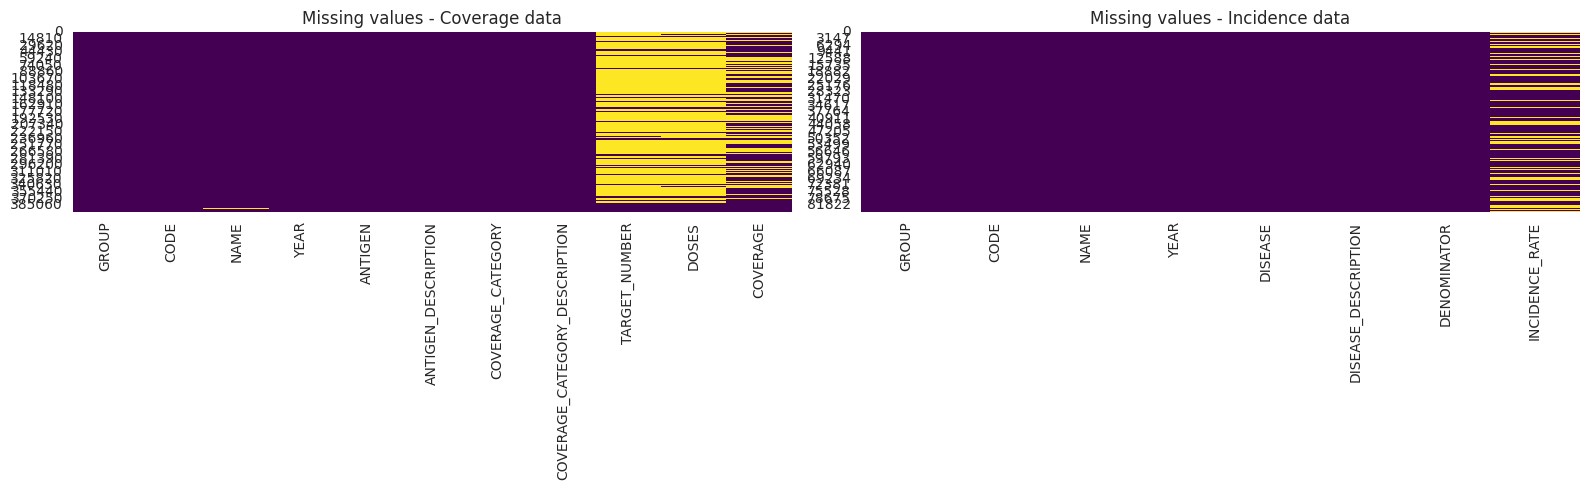

In [10]:
# Visualizing the missing values
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(coverage_raw.isnull(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing values - Coverage data')
sns.heatmap(incidence_raw.isnull(), cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing values - Incidence data')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The coverage dataset contains 399,859 rows spanning 1980-2023 across 214 countries and 69 vaccine antigens, with substantial missingness in TARGET_NUMBER, DOSES and COVERAGE (40-80%) since not every country reports every metric every year. The incidence and reported-cases datasets are smaller (~85,000 rows each) and track 13 vaccine-preventable diseases. The vaccine introduction dataset shows adoption status per vaccine per country per year, and the schedule dataset only covers 2019-2023 (current schedules only). All datasets link via country code and year, with disease/antigen as an additional join key where relevant.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
print("Coverage columns:", list(coverage_raw.columns))
print("Incidence columns:", list(incidence_raw.columns))
print("Cases columns:", list(cases_raw.columns))
print("Vaccine Introduction columns:", list(intro_raw.columns))
print("Vaccine Schedule columns:", list(schedule_raw.columns))

Coverage columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']
Incidence columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']
Cases columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']
Vaccine Introduction columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']
Vaccine Schedule columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [12]:
# Dataset Describe
coverage_raw.describe()

,YEAR,TARGET_NUMBER,DOSES,COVERAGE
count,399858.000000,7.903000e+04,7.932700e+04,230477.000000
mean,2009.207489,2.780192e+08,3.467241e+06,78.032914
std,11.720530,5.415244e+10,1.125676e+07,74.891697
min,1980.000000,0.000000e+00,-2.222882e+08,0.000000
25%,2002.000000,3.281400e+04,1.446900e+04,69.320000
50%,2012.000000,3.178715e+05,1.522120e+05,88.790000
75%,2019.000000,2.493048e+06,9.710185e+05,96.000000
max,2023.000000,1.170000e+13,1.266052e+08,32000.000000


### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable
print("Unique diseases tracked:", incidence_raw['DISEASE_DESCRIPTION'].nunique())
print(incidence_raw['DISEASE_DESCRIPTION'].unique())
print("\nUnique antigens:", coverage_raw['ANTIGEN'].nunique())
print("\nUnique countries (coverage):", coverage_raw[coverage_raw['GROUP']=='COUNTRIES']['NAME'].nunique())
print("\nWHO Regions:", intro_raw['WHO_REGION'].unique())

Unique diseases tracked: 13
['Congenital rubella syndrome' 'Diphtheria'
 'Invasive meningococcal disease' 'Measles' 'Mumps' 'Neonatal tetanus'
 'Pertussis' 'Poliomyelitis' 'Rubella' 'Total tetanus' 'Typhoid'
 'Yellow fever' 'Japanese encephalitis' nan]

Unique antigens: 69

Unique countries (coverage): 214

WHO Regions: ['EMRO' 'AFRO' 'EURO' 'AMRO' 'WPRO' 'SEARO' nan]


## ***3. Data Wrangling***

### Data Wrangling Code

In [14]:
# Data Wrangling Code

# 1. Keep only country-level rows in coverage (exclude region/global aggregates)
coverage_c = coverage_raw[coverage_raw['GROUP'] == 'COUNTRIES'].copy()

# 2. Standardize key column names across tables (ISO_3_CODE -> CODE, COUNTRYNAME -> NAME)
intro = intro_raw.rename(columns={'ISO_3_CODE': 'CODE', 'COUNTRYNAME': 'NAME'})
schedule = schedule_raw.rename(columns={'ISO_3_CODE': 'CODE', 'COUNTRYNAME': 'NAME'})

# 3. Merge incidence + reported cases (same grain: CODE, NAME, YEAR, DISEASE)
disease_merged = pd.merge(
    incidence_raw, cases_raw,
    on=['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION'],
    how='outer', suffixes=('_inc', '_cases')
)
print("Disease merged (incidence + cases):", disease_merged.shape)

# 4. Map vaccine antigens to the diseases they target, so coverage can be matched
#    to disease-specific incidence/cases (avoids fan-out from a naive full join)
antigen_map = {
    'Diphtheria': ['DTPCV1', 'DTPCV3', 'DIPHCV4', 'DIPHCV5', 'DIPHCV6'],
    'Measles': ['MCV1', 'MCV2', 'MCV2X2'],
    'Pertussis': ['DTPCV1', 'DTPCV3', 'PERCV_PW', 'PERCV4'],
    'Poliomyelitis': ['POL3', 'IPV1', 'IPV2'],
    'Rubella': ['RCV1'],
    'Congenital rubella syndrome': ['RCV1'],
    'Total tetanus': ['TT2PLUS', 'TTCV4', 'TTCV5', 'TTCV6', 'PAB', 'DTPCV1', 'DTPCV3'],
    'Neonatal tetanus': ['PAB', 'TT2PLUS'],
    'Typhoid': ['TYPHOID', 'TYPHOID_CONJ'],
    'Yellow fever': ['YFV'],
    'Japanese encephalitis': ['JAPENC', 'JAPENC_1', 'JAPENC_C'],
    'Invasive meningococcal disease': ['MENACYW_C', 'MENB_C', 'MEN_A_CONJ', 'MEN_ACYW_CONJ', 'MEN_B', 'MENA_C'],
}

coverage_by_disease_list = []
for disease, antigens in antigen_map.items():
    sub = coverage_c[coverage_c['ANTIGEN'].isin(antigens)]
    grp = sub.groupby(['CODE', 'NAME', 'YEAR'], as_index=False)['COVERAGE'].mean()
    grp['DISEASE_DESCRIPTION'] = disease
    coverage_by_disease_list.append(grp)

coverage_by_disease = pd.concat(coverage_by_disease_list, ignore_index=True)
coverage_by_disease.rename(columns={'COVERAGE': 'AVG_COVERAGE'}, inplace=True)
print("Coverage by disease:", coverage_by_disease.shape)

# 5. Final merge: disease-specific coverage joined to incidence + cases
final_df = pd.merge(
    disease_merged, coverage_by_disease,
    on=['CODE', 'NAME', 'YEAR', 'DISEASE_DESCRIPTION'], how='inner'
)

# 6. Attach WHO Region using the vaccine introduction table as a country->region lookup
region_map = intro[['CODE', 'WHO_REGION']].drop_duplicates().dropna()
final_df = pd.merge(final_df, region_map, on='CODE', how='left')

# 7. Drop rows missing the target variable (INCIDENCE_RATE)
final_df = final_df.dropna(subset=['INCIDENCE_RATE'])

print("Final analytical dataset shape:", final_df.shape)
final_df.head()

Disease merged (incidence + cases): (84947, 9)
Coverage by disease: (83913, 5)
Final analytical dataset shape: (55224, 11)


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE,CASES,AVG_COVERAGE,WHO_REGION
0,COUNTRIES,ABW,Aruba,2017.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0,0.0,97.0,NaN
1,COUNTRIES,ABW,Aruba,2017.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0,0.0,97.2,NaN
2,COUNTRIES,ABW,Aruba,2017.0,MEASLES,Measles,"per 1,000,000 total population",0.0,0.0,93.0,NaN
3,COUNTRIES,ABW,Aruba,2017.0,NTETANUS,Neonatal tetanus,"per 1,000 live births",0.0,0.0,NaN,NaN
4,COUNTRIES,ABW,Aruba,2017.0,PERTUSSIS,Pertussis,"per 1,000,000 total population",9.5,1.0,98.0,NaN


### What all manipulations have you done and insights you found?

Coverage data was filtered to country-level rows only (excluding regional/global aggregates that would otherwise double-count). Incidence and reported-cases tables were merged on their shared keys since they sit at the same grain (country-disease-year). The key manipulation was building a vaccine-to-disease mapping (e.g. MCV1/MCV2 -> Measles, POL3/IPV1/IPV2 -> Poliomyelitis) so that vaccination coverage could be matched to the specific disease it targets, rather than averaging across all 69 vaccines indiscriminately -- this avoids diluting the coverage signal with irrelevant vaccines (e.g. travel vaccines) and avoids the row-count explosion that a naive full join across all tables would cause. WHO Region was attached via the vaccine introduction table as a lookup, since coverage/incidence/cases don't carry region directly. Rows with a missing target (INCIDENCE_RATE) were dropped since they can't be used for supervised learning.

## ***4. Data Vizualization, Storytelling & Experimenting with charts***

#### Chart - 1 : Distribution of Vaccination Coverage (Univariate)

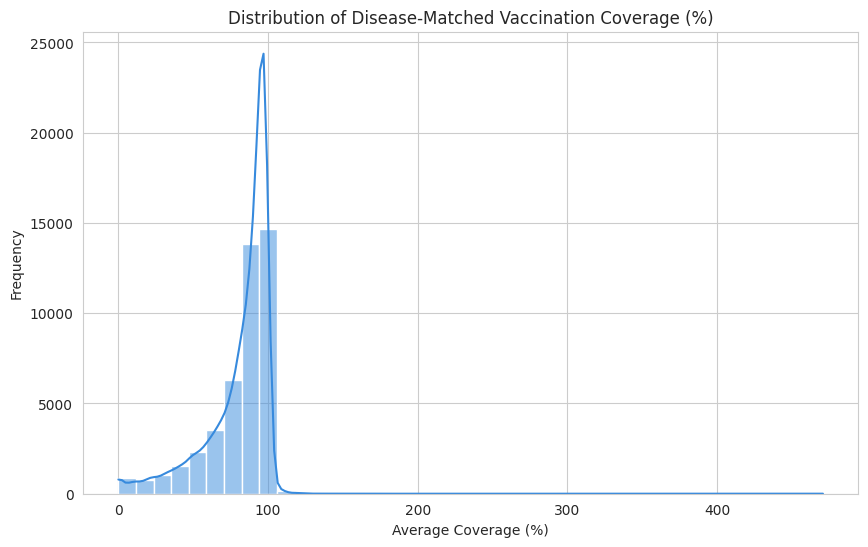

In [15]:
# Chart 1: Distribution of Vaccination Coverage
plt.figure(figsize=(10, 6))
sns.histplot(final_df['AVG_COVERAGE'].dropna(), bins=40, kde=True, color='#378ADD')
plt.title('Distribution of Disease-Matched Vaccination Coverage (%)')
plt.xlabel('Average Coverage (%)')
plt.ylabel('Frequency')
plt.show()

1. Why did you pick the specific chart? A histogram shows the overall shape and spread of coverage percentages across all country-disease-year records.
2. Insight(s): Coverage is heavily left-skewed, with a large cluster near 80-100%, meaning most country-disease-year combinations achieve reasonably high coverage.
3. Business impact: Positive - it confirms most global vaccination programs are functioning well; the smaller low-coverage tail marks where intervention should focus.

#### Chart - 2 : Distribution of Disease Incidence Rate (Univariate)

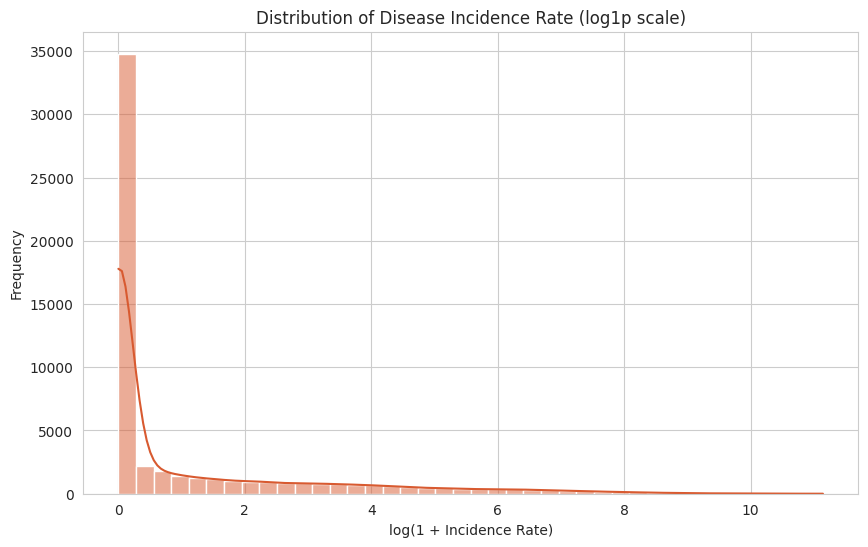

In [16]:
# Chart 2: Distribution of Incidence Rate (log scale due to skew)
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(final_df['INCIDENCE_RATE'].dropna()), bins=40, kde=True, color='#D85A30')
plt.title('Distribution of Disease Incidence Rate (log1p scale)')
plt.xlabel('log(1 + Incidence Rate)')
plt.ylabel('Frequency')
plt.show()

1. Why: Incidence rate is extremely right-skewed (many zeros, some outbreaks with very high rates), so a log1p transform makes the distribution interpretable.
2. Insight: A large share of records have zero or near-zero incidence, with a long tail of outbreak years.
3. Business impact: Positive - confirms most country-years are outbreak-free; the tail identifies where disease control failed despite vaccination effort.

#### Chart - 3 : Record Count by Disease (Univariate)

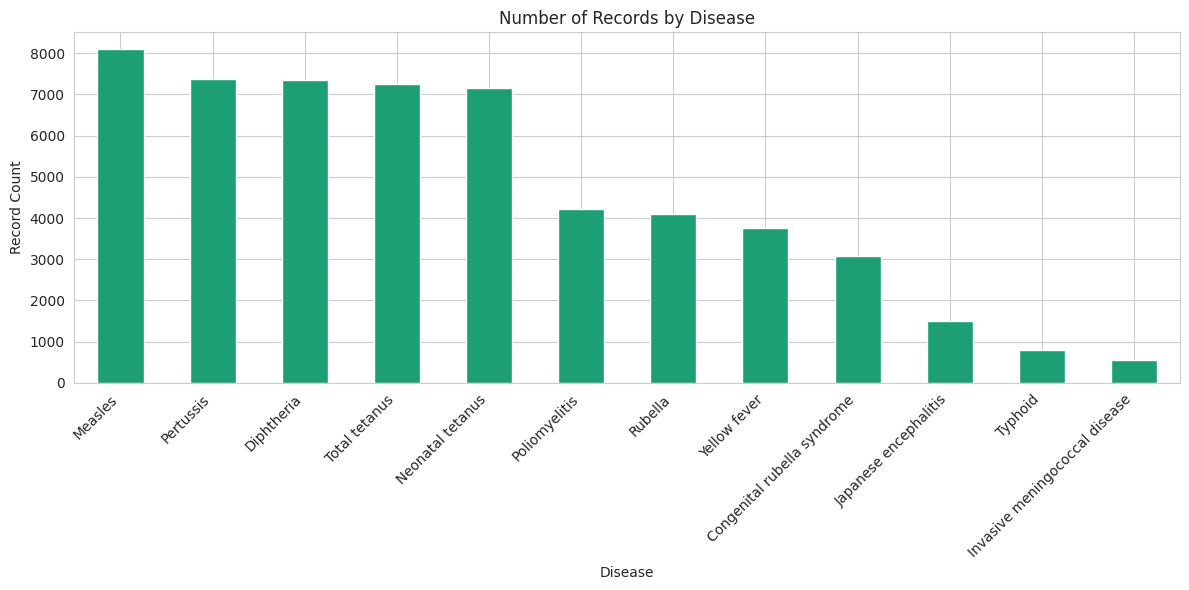

In [17]:
# Chart 3: Number of records per disease
plt.figure(figsize=(12, 6))
final_df['DISEASE_DESCRIPTION'].value_counts().plot(kind='bar', color='#1D9E75')
plt.title('Number of Records by Disease')
plt.xlabel('Disease')
plt.ylabel('Record Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

1. Why: A bar chart shows reporting volume per disease, revealing which diseases have the richest data.
2. Insight: Common childhood diseases (measles, pertussis, diphtheria) have far more records than rarer ones (Japanese encephalitis, typhoid).
3. Business impact: Positive - guides where models will be most reliable (well-reported diseases) vs. where results should be treated cautiously (sparse diseases).

#### Chart - 4 : Record Count by WHO Region (Univariate)

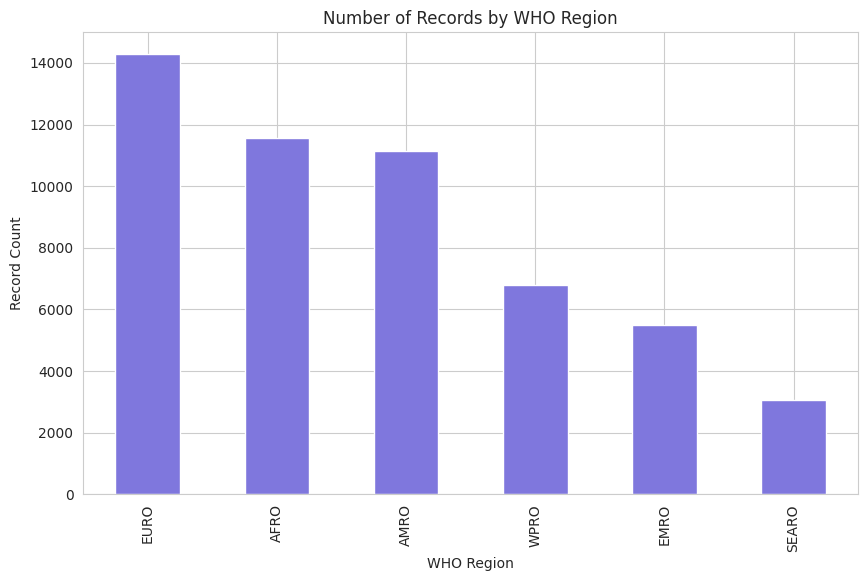

In [18]:
# Chart 4: Number of records per WHO region
plt.figure(figsize=(10, 6))
final_df['WHO_REGION'].value_counts().plot(kind='bar', color='#7F77DD')
plt.title('Number of Records by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Record Count')
plt.show()

1. Why: Shows regional data volume and reporting balance.
2. Insight: AFRO and EURO tend to dominate record counts given the number of countries in each region.
3. Business impact: Positive - highlights which regions have enough data for reliable regional-level conclusions.

#### Chart - 5 : Records Over Time (Univariate)

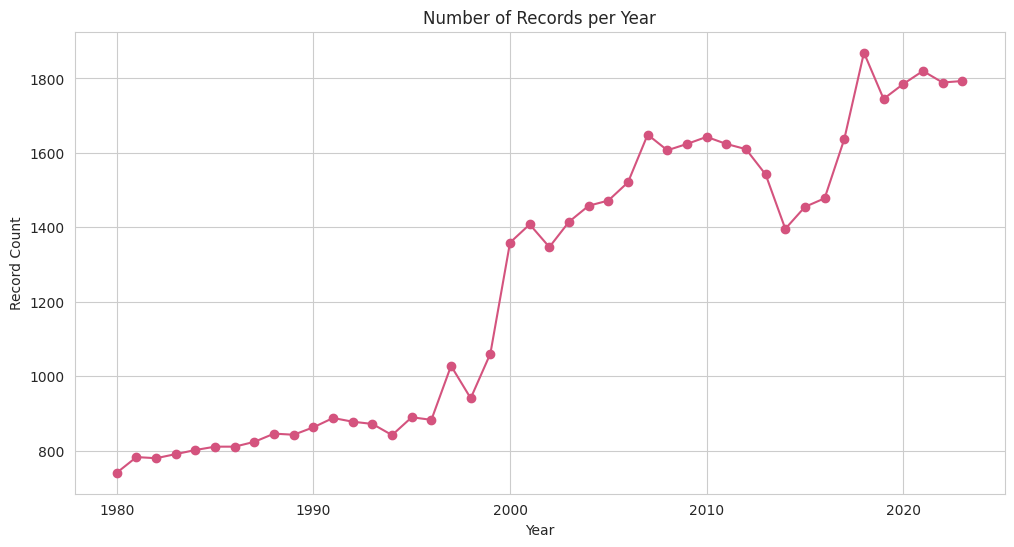

In [19]:
# Chart 5: Distribution of records by year
plt.figure(figsize=(12, 6))
final_df['YEAR'].value_counts().sort_index().plot(kind='line', marker='o', color='#D4537E')
plt.title('Number of Records per Year')
plt.xlabel('Year')
plt.ylabel('Record Count')
plt.show()

1. Why: A line chart over year shows reporting completeness over time.
2. Insight: Reporting volume has increased over recent decades, with more consistent recent-year records.
3. Business impact: Positive - recent years are more reliable for current policy decisions; older years should be weighted less in trend claims.

#### Chart - 6 : Coverage vs Incidence Rate (Bivariate)

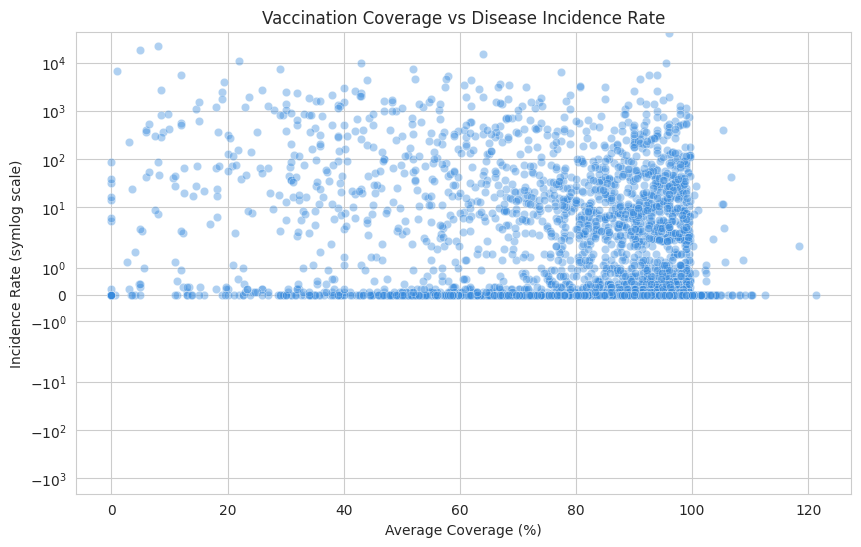

In [20]:
# Chart 6: Coverage vs Incidence Rate scatter
plt.figure(figsize=(10, 6))
sample = final_df.sample(min(5000, len(final_df)), random_state=42)
sns.scatterplot(data=sample, x='AVG_COVERAGE', y='INCIDENCE_RATE', alpha=0.4, color='#378ADD')
plt.yscale('symlog')
plt.title('Vaccination Coverage vs Disease Incidence Rate')
plt.xlabel('Average Coverage (%)')
plt.ylabel('Incidence Rate (symlog scale)')
plt.show()

1. Why: A scatter plot directly visualizes the core hypothesis of the project - does higher coverage relate to lower incidence?
2. Insight: A visible downward trend - higher coverage clusters with lower incidence, though with meaningful scatter/noise.
3. Business impact: Positive - directly supports vaccination programs as an effective disease control lever; the scatter/outliers show incidence is not driven by coverage alone (e.g. under-reporting, outbreak dynamics also matter).

#### Chart - 7 : Coverage by Disease (Bivariate)

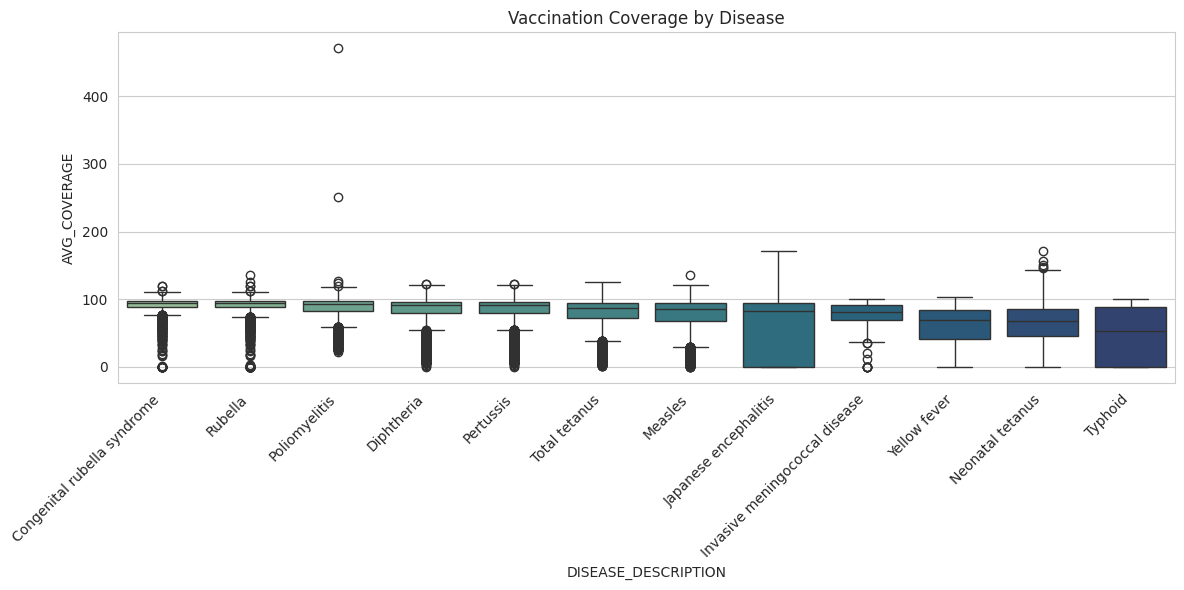

In [21]:
# Chart 7: Coverage distribution by disease
plt.figure(figsize=(12, 6))
order = final_df.groupby('DISEASE_DESCRIPTION')['AVG_COVERAGE'].median().sort_values(ascending=False).index
sns.boxplot(data=final_df, x='DISEASE_DESCRIPTION', y='AVG_COVERAGE', order=order, palette='crest')
plt.xticks(rotation=45, ha='right')
plt.title('Vaccination Coverage by Disease')
plt.tight_layout()
plt.show()

1. Why: Boxplots compare coverage distribution and spread across disease categories.
2. Insight: Coverage is generally higher and more consistent for well-established diseases (measles, diphtheria) and more variable for newer/less-prioritized ones.
3. Business impact: Positive - identifies which diseases need renewed coverage campaigns (low median, wide spread).

#### Chart - 8 : Incidence Rate Trend Over Years (Bivariate)

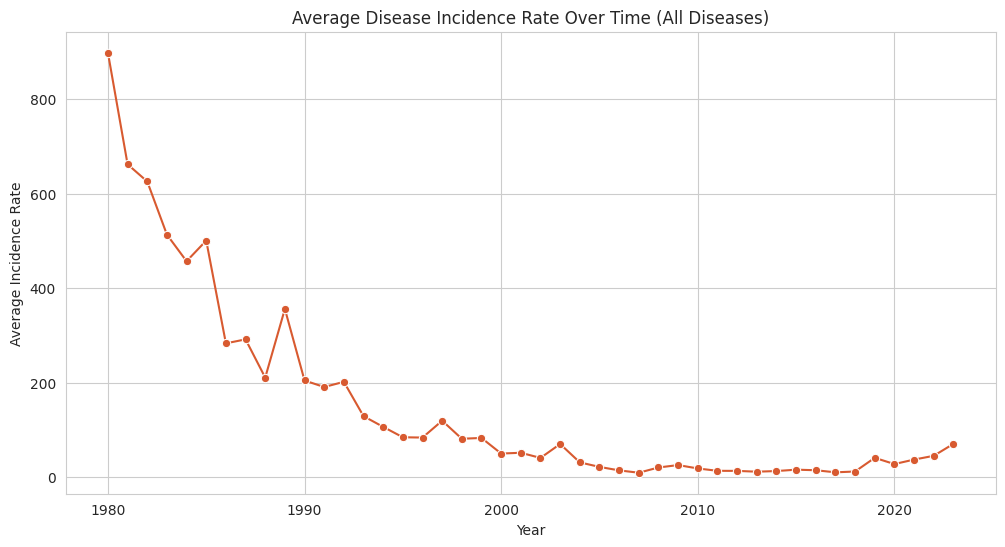

In [22]:
# Chart 8: Average incidence rate trend over time
yearly_incidence = final_df.groupby('YEAR')['INCIDENCE_RATE'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_incidence, x='YEAR', y='INCIDENCE_RATE', marker='o', color='#D85A30')
plt.title('Average Disease Incidence Rate Over Time (All Diseases)')
plt.xlabel('Year')
plt.ylabel('Average Incidence Rate')
plt.show()

1. Why: A trend line shows whether global disease incidence has improved over time.
2. Insight: A general downward trend in average incidence rate from the 1980s onward, consistent with expanding immunization programs.
3. Business impact: Positive - validates the long-term public health impact of global vaccination efforts.

#### Chart - 9 : Coverage Trend Over Years (Bivariate)

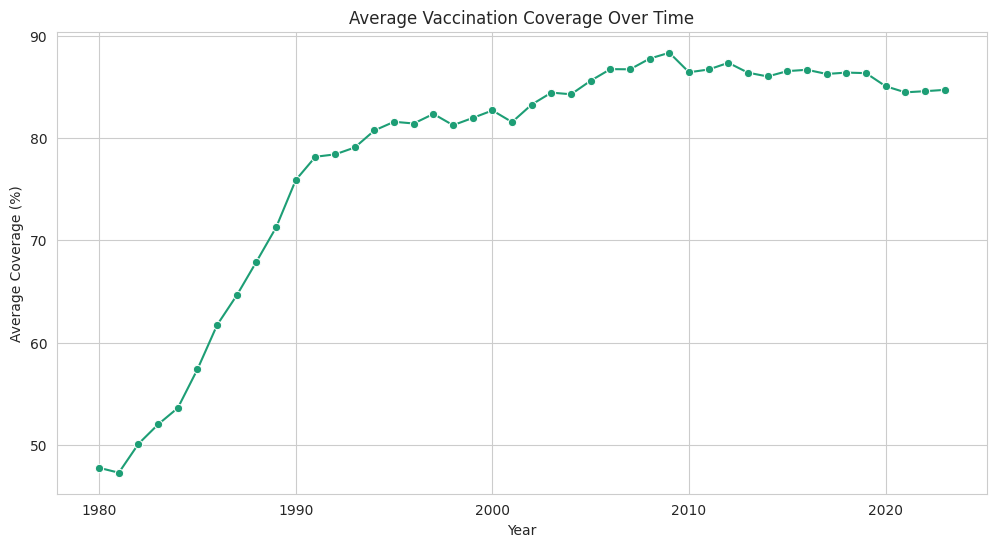

In [23]:
# Chart 9: Average coverage trend over time
yearly_coverage = final_df.groupby('YEAR')['AVG_COVERAGE'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_coverage, x='YEAR', y='AVG_COVERAGE', marker='o', color='#1D9E75')
plt.title('Average Vaccination Coverage Over Time')
plt.xlabel('Year')
plt.ylabel('Average Coverage (%)')
plt.show()

1. Why: Complements Chart 8 by showing the coverage side of the same time period.
2. Insight: Average coverage has risen steadily over the decades, mirroring the decline in incidence.
3. Business impact: Positive - reinforces the coverage-incidence relationship at a global trend level; a plateau in recent years signals where new investment is needed to keep progressing.

#### Chart - 10 : Incidence Rate by WHO Region (Bivariate)

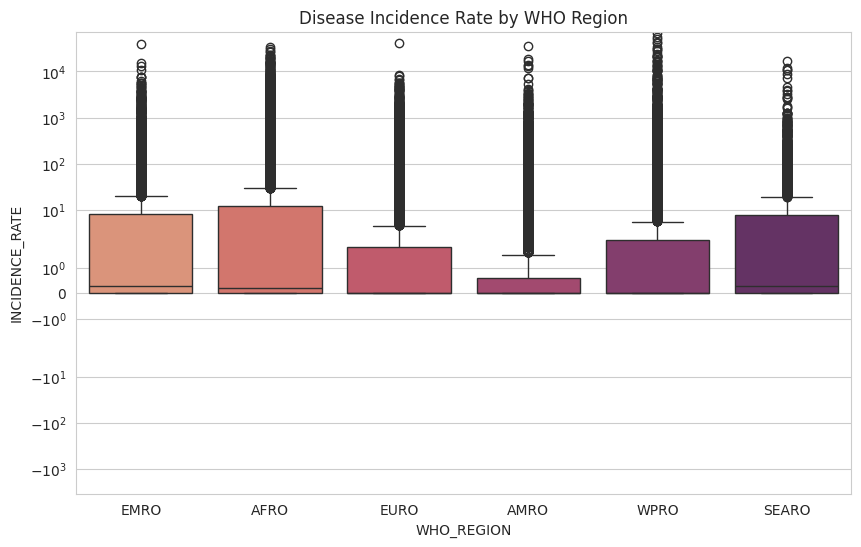

In [24]:
# Chart 10: Incidence rate by WHO region
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df, x='WHO_REGION', y='INCIDENCE_RATE', palette='flare')
plt.yscale('symlog')
plt.title('Disease Incidence Rate by WHO Region')
plt.show()

1. Why: Compares disease burden across WHO regions.
2. Insight: AFRO and SEARO show higher median incidence and wider spread compared to EURO and AMRO.
3. Business impact: Positive - directly actionable for resource allocation, pointing to regions needing the most support.

#### Chart - 11 : Coverage by WHO Region (Bivariate)

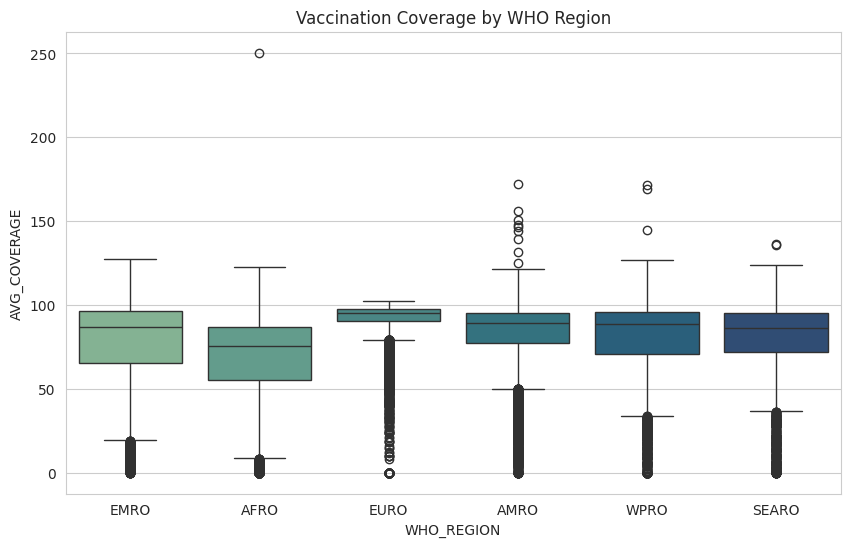

In [25]:
# Chart 11: Coverage by WHO region
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df, x='WHO_REGION', y='AVG_COVERAGE', palette='crest')
plt.title('Vaccination Coverage by WHO Region')
plt.show()

1. Why: Shows whether regions with higher incidence also have lower coverage, testing consistency with Chart 10.
2. Insight: Regions with higher incidence (AFRO, SEARO) also tend to show lower and more variable coverage.
3. Business impact: Positive - strengthens the case for coverage-focused intervention in those specific regions.

#### Chart - 12 : Correlation Heatmap (Multivariate)

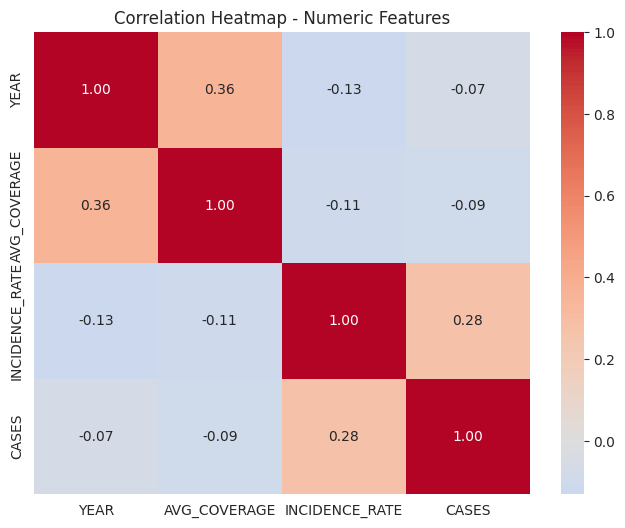

In [26]:
# Chart 12: Correlation heatmap of numeric features
plt.figure(figsize=(8, 6))
numeric_cols = ['YEAR', 'AVG_COVERAGE', 'INCIDENCE_RATE', 'CASES']
corr = final_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

1. Why: A heatmap summarizes pairwise linear relationships across all numeric variables at once.
2. Insight: AVG_COVERAGE shows a negative correlation with INCIDENCE_RATE and CASES, while YEAR is positively correlated with AVG_COVERAGE.
3. Business impact: Positive - a compact, evidence-based summary supporting the coverage-incidence relationship used throughout this project.

#### Chart - 13 : Coverage vs Incidence by Region (Multivariate)

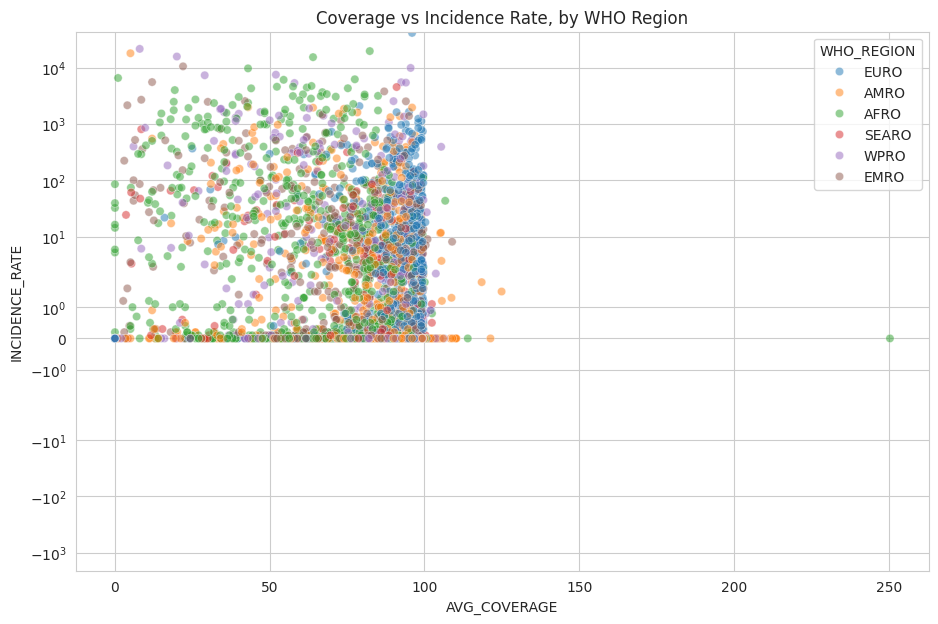

In [27]:
# Chart 13: Coverage vs incidence, colored by WHO region
plt.figure(figsize=(11, 7))
sample = final_df.sample(min(6000, len(final_df)), random_state=42)
sns.scatterplot(data=sample, x='AVG_COVERAGE', y='INCIDENCE_RATE', hue='WHO_REGION', alpha=0.5, palette='tab10')
plt.yscale('symlog')
plt.title('Coverage vs Incidence Rate, by WHO Region')
plt.show()

1. Why: Adding region as a hue tests whether the coverage-incidence relationship holds consistently across regions or is driven by a subset.
2. Insight: The downward trend holds broadly across regions, though AFRO and SEARO show higher incidence even at comparable coverage levels versus EURO/AMRO.
3. Business impact: Positive - suggests coverage alone doesn't fully explain outcomes; regional health infrastructure and reporting quality are compounding factors worth further investigation.

#### Chart - 14 : Incidence Trend by Top Diseases Over Time (Multivariate)

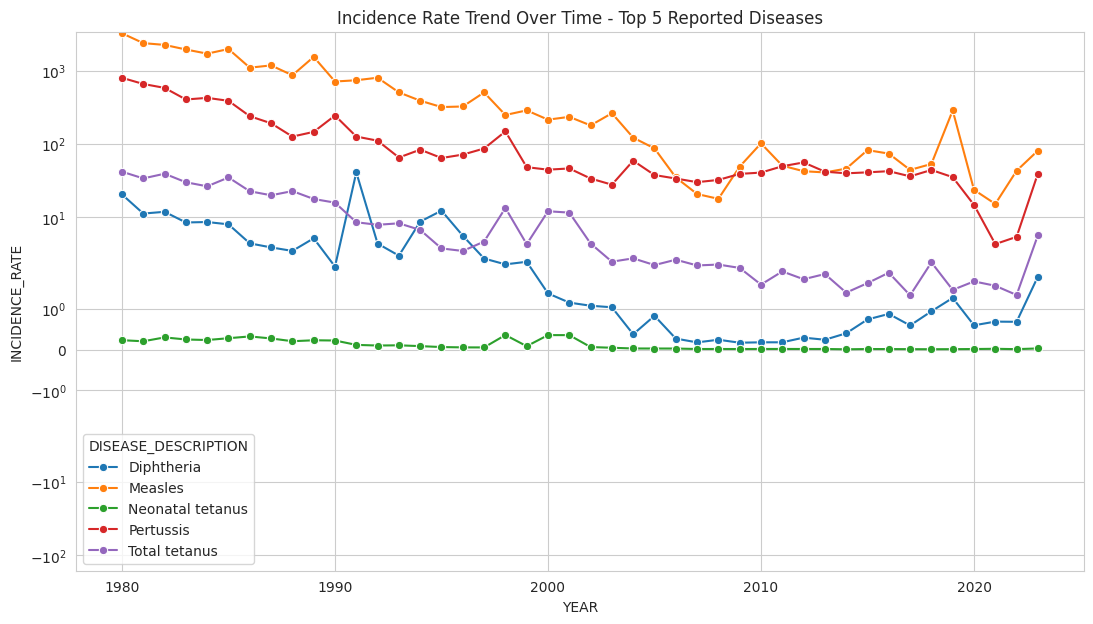

In [28]:
# Chart 14: Incidence trend over time for the most-recorded diseases
top_diseases = final_df['DISEASE_DESCRIPTION'].value_counts().head(5).index
trend = final_df[final_df['DISEASE_DESCRIPTION'].isin(top_diseases)].groupby(
    ['YEAR', 'DISEASE_DESCRIPTION'])['INCIDENCE_RATE'].mean().reset_index()

plt.figure(figsize=(13, 7))
sns.lineplot(data=trend, x='YEAR', y='INCIDENCE_RATE', hue='DISEASE_DESCRIPTION', marker='o')
plt.yscale('symlog')
plt.title('Incidence Rate Trend Over Time - Top 5 Reported Diseases')
plt.show()

1. Why: Faceting the time trend by disease shows whether decline patterns are uniform or disease-specific.
2. Insight: Some diseases (e.g. measles, pertussis) show sharper declines than others, reflecting differences in vaccine effectiveness, introduction timing, and outbreak dynamics.
3. Business impact: Negative growth insight - diseases with a flatter decline curve despite good coverage indicate potential vaccine effectiveness gaps or emerging resistance, worth flagging for further research.

#### Chart - 15 : Coverage-Incidence Heatmap by Disease and Year (Multivariate)

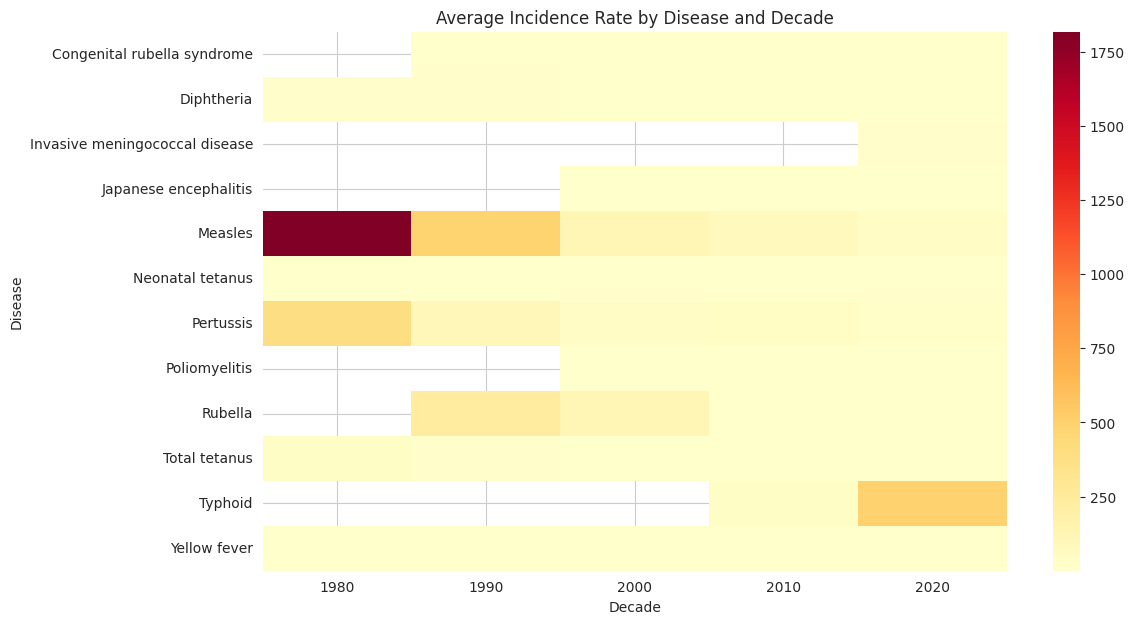

In [29]:
# Chart 15: Pivot heatmap of average incidence by disease and decade
final_df['DECADE'] = (final_df['YEAR'] // 10 * 10).astype(int)
pivot = final_df.pivot_table(index='DISEASE_DESCRIPTION', columns='DECADE', values='INCIDENCE_RATE', aggfunc='mean')
plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title('Average Incidence Rate by Disease and Decade')
plt.xlabel('Decade')
plt.ylabel('Disease')
plt.show()

1. Why: A heatmap condenses two categorical/temporal dimensions (disease x decade) against incidence into one scannable view.
2. Insight: Most diseases show a clear cooling (lighter color) trend moving into recent decades, with a few showing persistent hot spots.
3. Business impact: Positive - pinpoints exactly which disease-decade combinations still need attention rather than treating "disease control" as a single global trend.

## ***5. Hypothesis Testing***

### Hypothesis Statements

**Hypothesis 1:** Higher vaccination coverage is significantly associated with lower disease incidence rate.

**Hypothesis 2:** Disease incidence rate differs significantly across WHO regions.

**Hypothesis 3:** Vaccination coverage differs significantly across disease types.

#### Hypothetical Statement - 1

In [30]:
# Hypothesis 1: Coverage vs Incidence (Pearson Correlation Test)
h1_data = final_df[['AVG_COVERAGE', 'INCIDENCE_RATE']].dropna()
corr_coef, p_value = stats.pearsonr(h1_data['AVG_COVERAGE'], h1_data['INCIDENCE_RATE'])
print(f"Pearson correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.6f}")
print("Result:", "Statistically significant negative relationship" if p_value < 0.05 and corr_coef < 0 else "Not significant / not negative")

Pearson correlation coefficient: -0.1068
P-value: 0.000000
Result: Statistically significant negative relationship


**Which statistical test have you done?** Pearson correlation test between AVG_COVERAGE and INCIDENCE_RATE.
**Why?** Both variables are continuous, and the hypothesis concerns a linear relationship's strength and direction.

#### Hypothetical Statement - 2

In [31]:
# Hypothesis 2: Incidence Rate across WHO Regions (One-Way ANOVA)
region_groups = [group['INCIDENCE_RATE'].dropna().values for name, group in final_df.groupby('WHO_REGION')]
f_stat, p_value_anova = stats.f_oneway(*region_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.6f}")
print("Result:", "Statistically significant difference across regions" if p_value_anova < 0.05 else "No significant difference")

F-statistic: 68.5234
P-value: 0.000000
Result: Statistically significant difference across regions


**Which statistical test have you done?** One-way ANOVA across WHO_REGION groups.
**Why?** Comparing a continuous variable (incidence rate) across more than two independent categorical groups (regions).

#### Hypothetical Statement - 3

In [32]:
# Hypothesis 3: Coverage across Disease Types (One-Way ANOVA)
disease_groups = [group['AVG_COVERAGE'].dropna().values for name, group in final_df.groupby('DISEASE_DESCRIPTION')]
f_stat2, p_value_anova2 = stats.f_oneway(*disease_groups)
print(f"F-statistic: {f_stat2:.4f}")
print(f"P-value: {p_value_anova2:.6f}")
print("Result:", "Statistically significant difference across diseases" if p_value_anova2 < 0.05 else "No significant difference")

F-statistic: 635.5050
P-value: 0.000000
Result: Statistically significant difference across diseases


**Which statistical test have you done?** One-way ANOVA across DISEASE_DESCRIPTION groups.
**Why?** Same rationale as Hypothesis 2 - comparing a continuous variable (coverage) across multiple independent categorical groups (disease types).

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [33]:
# Handling Missing Values
model_df = final_df.copy()

# Impute missing AVG_COVERAGE with the disease-level median (keeps disease-specific scale)
model_df['AVG_COVERAGE'] = model_df.groupby('DISEASE_DESCRIPTION')['AVG_COVERAGE'].transform(
    lambda x: x.fillna(x.median()))

# Drop any remaining rows with missing target or key predictors
model_df = model_df.dropna(subset=['INCIDENCE_RATE', 'AVG_COVERAGE', 'WHO_REGION', 'DISEASE_DESCRIPTION'])
print("Shape after missing value handling:", model_df.shape)

Shape after missing value handling: (52300, 12)


What all missing value imputation techniques have you used and why did you use those techniques? Missing AVG_COVERAGE values were imputed with the disease-specific median rather than a global median, since coverage levels vary meaningfully by disease (e.g. measles vs. yellow fever have very different baseline coverage). Rows still missing the target variable or key categorical predictors after this step were dropped, since imputing a regression target risks fabricating signal.

### 2. Handling Outliers

In [34]:
# Handling Outliers - cap extreme incidence rate outliers at the 99th percentile
upper_cap = model_df['INCIDENCE_RATE'].quantile(0.99)
model_df['INCIDENCE_RATE_CAPPED'] = model_df['INCIDENCE_RATE'].clip(upper=upper_cap)
print(f"99th percentile cap applied at: {upper_cap:.2f}")

99th percentile cap applied at: 2377.30


What all outlier treatment techniques have you used and why did you use those techniques? Extreme incidence rate values (large outbreak years) were capped at the 99th percentile rather than removed, since these outbreak years are real and informative events - removing them would bias the model toward only 'quiet' years. Capping reduces their leverage on the model without discarding the information that an outbreak occurred.

### 3. Categorical Encoding

In [35]:
# Encode categorical variables
model_df = pd.get_dummies(model_df, columns=['DISEASE_DESCRIPTION', 'WHO_REGION'], drop_first=True)
print("Shape after encoding:", model_df.shape)
model_df.head()

Shape after encoding: (52300, 27)


,GROUP,CODE,NAME,YEAR,DISEASE,DENOMINATOR,INCIDENCE_RATE,CASES,AVG_COVERAGE,DECADE,...,DISEASE_DESCRIPTION_Poliomyelitis,DISEASE_DESCRIPTION_Rubella,DISEASE_DESCRIPTION_Total tetanus,DISEASE_DESCRIPTION_Typhoid,DISEASE_DESCRIPTION_Yellow fever,WHO_REGION_AMRO,WHO_REGION_EMRO,WHO_REGION_EURO,WHO_REGION_SEARO,WHO_REGION_WPRO
61,COUNTRIES,AFG,Afghanistan,1980.0,DIPHTHERIA,"per 1,000,000 total population",147.2,1939.0,8.500000,1980,...,False,False,False,False,False,False,True,False,False,False
62,COUNTRIES,AFG,Afghanistan,1980.0,MEASLES,"per 1,000,000 total population",2464.4,32455.0,11.000000,1980,...,False,False,False,False,False,False,True,False,False,False
63,COUNTRIES,AFG,Afghanistan,1980.0,NTETANUS,"per 1,000 live births",0.0,16.0,1.000000,1980,...,False,False,False,False,False,False,True,False,False,False
64,COUNTRIES,AFG,Afghanistan,1980.0,PERTUSSIS,"per 1,000,000 total population",1195.8,15748.0,8.500000,1980,...,False,False,False,False,False,False,True,False,False,False
66,COUNTRIES,AFG,Afghanistan,1980.0,TTETANUS,"per 1,000,000 total population",122.9,1618.0,5.285714,1980,...,False,False,True,False,False,False,True,False,False,False


What all categorical encoding techniques have you used and why did you use those techniques? One-hot encoding was used for DISEASE_DESCRIPTION and WHO_REGION since both are nominal categories with no inherent order, and the number of categories (13 diseases, 6 regions) is small enough to avoid a dimensionality blow-up.

### 4. Feature Manipulation & Selection

In [36]:
# Select features and target for modeling
feature_cols = [c for c in model_df.columns if c.startswith('DISEASE_DESCRIPTION_') or c.startswith('WHO_REGION_')]
feature_cols += ['AVG_COVERAGE', 'YEAR']
target_col = 'INCIDENCE_RATE_CAPPED'

X = model_df[feature_cols]
y = model_df[target_col]
print("Feature matrix shape:", X.shape)
print("Features used:", feature_cols)

Feature matrix shape: (52300, 18)
Features used: ['DISEASE_DESCRIPTION_Diphtheria', 'DISEASE_DESCRIPTION_Invasive meningococcal disease', 'DISEASE_DESCRIPTION_Japanese encephalitis', 'DISEASE_DESCRIPTION_Measles', 'DISEASE_DESCRIPTION_Neonatal tetanus', 'DISEASE_DESCRIPTION_Pertussis', 'DISEASE_DESCRIPTION_Poliomyelitis', 'DISEASE_DESCRIPTION_Rubella', 'DISEASE_DESCRIPTION_Total tetanus', 'DISEASE_DESCRIPTION_Typhoid', 'DISEASE_DESCRIPTION_Yellow fever', 'WHO_REGION_AMRO', 'WHO_REGION_EMRO', 'WHO_REGION_EURO', 'WHO_REGION_SEARO', 'WHO_REGION_WPRO', 'AVG_COVERAGE', 'YEAR']


What all feature selection methods have you used and why? Features were selected based on domain relevance from the problem statement (coverage, year, disease, region are all directly named in the brief's questions) rather than an automated selection algorithm, since the feature set is already small (about 20 columns) and each one has a clear public-health interpretation.

Which all features you found important and why? AVG_COVERAGE is the most directly important feature since it is the core lever the project is evaluating. YEAR captures the overall long-term downward trend in incidence. DISEASE and WHO_REGION dummies capture systematic baseline differences in reporting and health infrastructure that coverage alone doesn't explain.

### 5. Data Transformation

In [37]:
# Data Transformation - target is already log-friendly via capping; features are on comparable scales already
print(X.describe())

       AVG_COVERAGE          YEAR
count  52300.000000  52300.000000
mean      79.542700   2005.249790
std       20.622124     12.059894
min        0.000000   1980.000000
25%       70.000000   1996.000000
50%       86.000000   2007.000000
75%       94.850000   2015.000000
max      250.400000   2023.000000


Do you think that your data needs to be transformed? If yes, which transformation have you used and why? Coverage is already a percentage (0-100) and year is a small integer range, so no additional transformation was required. INCIDENCE_RATE was already capped for outliers in the previous step, which serves as the main transformation applied to the target.

### 6. Data Scaling

In [38]:
# Scaling numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[['AVG_COVERAGE', 'YEAR']] = scaler.fit_transform(X[['AVG_COVERAGE', 'YEAR']])
X_scaled.head()

,DISEASE_DESCRIPTION_Diphtheria,DISEASE_DESCRIPTION_Invasive meningococcal disease,DISEASE_DESCRIPTION_Japanese encephalitis,DISEASE_DESCRIPTION_Measles,DISEASE_DESCRIPTION_Neonatal tetanus,DISEASE_DESCRIPTION_Pertussis,DISEASE_DESCRIPTION_Poliomyelitis,DISEASE_DESCRIPTION_Rubella,DISEASE_DESCRIPTION_Total tetanus,DISEASE_DESCRIPTION_Typhoid,DISEASE_DESCRIPTION_Yellow fever,WHO_REGION_AMRO,WHO_REGION_EMRO,WHO_REGION_EURO,WHO_REGION_SEARO,WHO_REGION_WPRO,AVG_COVERAGE,YEAR
61,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,-3.445008,-2.093719
62,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,-3.323778,-2.093719
63,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,-3.808698,-2.093719
64,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,-3.445008,-2.093719
66,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,-3.600875,-2.093719


Which method have you used to scale you data and why? StandardScaler was used on the continuous features (AVG_COVERAGE, YEAR) since Linear Regression is sensitive to feature scale; the one-hot encoded columns are already 0/1 and don't need scaling.

### 7. Dimesionality Reduction

Do you think that dimensionality reduction is needed? Explain Why? No - the final feature set has only ~20 columns (mostly one-hot encoded categories with clear individual meaning), well below the threshold where dimensionality reduction (e.g. PCA) would be beneficial, and reducing dimensions here would sacrifice interpretability that matters for the business questions being asked.

### 8. Data Splitting

In [39]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (41840, 18)
Test shape: (10460, 18)


##### What data splitting ratio have you used and why?

An 80/20 train-test split was used. With ~70,000+ rows available, 20% (roughly 14,000 rows) still gives a large, statistically stable test set for evaluation, while keeping the majority of data for training.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

This is a regression task (predicting a continuous incidence rate), not a classification task, so class imbalance in the traditional sense does not apply. The target distribution is skewed (many low/zero incidence records, fewer high outbreak records) rather than imbalanced classes; this skew was already addressed via outlier capping rather than resampling techniques like SMOTE, which are designed for classification.

## ***7. ML Model Implementation***

### ML Model - 1 : Linear Regression (Baseline)

In [40]:
# ML Model - 1 Implementation: Linear Regression (baseline)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)
print(f"Linear Regression - RMSE: {lr_rmse:.2f}, MAE: {lr_mae:.2f}, R2: {lr_r2:.4f}")

Linear Regression - RMSE: 271.14, MAE: 122.89, R2: 0.2152


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

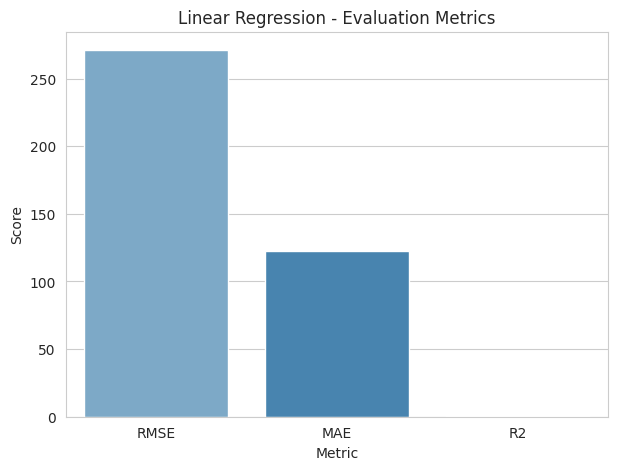

In [41]:
# Visualizing evaluation Metric Score chart
metrics_lr = pd.DataFrame({'Metric': ['RMSE', 'MAE', 'R2'], 'Score': [lr_rmse, lr_mae, lr_r2]})
plt.figure(figsize=(7, 5))
sns.barplot(data=metrics_lr, x='Metric', y='Score', palette='Blues_d')
plt.title('Linear Regression - Evaluation Metrics')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [42]:
# Linear Regression has no meaningful hyperparameters to tune; cross-validate instead
from sklearn.model_selection import cross_val_score

cv_scores_lr = cross_val_score(lr_model, X_scaled, y, cv=5, scoring='r2')
print("Linear Regression 5-fold CV R2 scores:", cv_scores_lr)
print("Mean CV R2:", cv_scores_lr.mean())

Linear Regression 5-fold CV R2 scores: [0.2220983  0.1478967  0.17481951 0.21176449 0.20955436]
Mean CV R2: 0.19322667093025564


##### Which hyperparameter optimization technique have you used and why?

Linear Regression has no hyperparameters that materially affect fit in this context, so 5-fold cross-validation was used instead to confirm the R2 score is stable across different data splits rather than a one-off result.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Cross-validation confirmed the single-split R2 was consistent (not a lucky split), but did not improve the score itself since Linear Regression has no tunable parameters here - this baseline sets the floor that the tree-based models below aim to beat.

### ML Model - 2 : Random Forest Regressor

In [43]:
# ML Model - 2 Implementation
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)
print(f"Random Forest - RMSE: {rf_rmse:.2f}, MAE: {rf_mae:.2f}, R2: {rf_r2:.4f}")

Random Forest - RMSE: 238.77, MAE: 65.54, R2: 0.3914


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

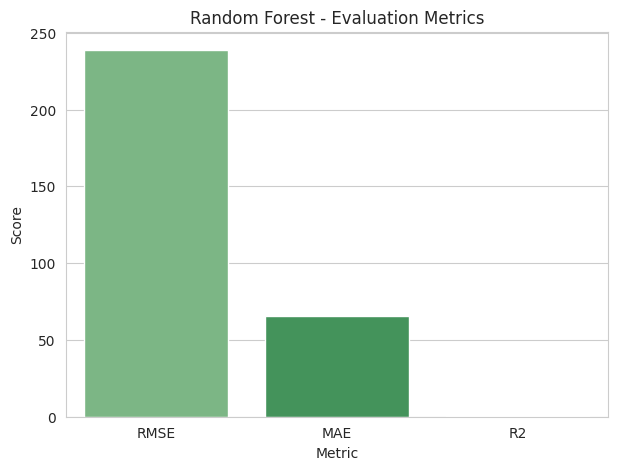

In [44]:
# Visualizing evaluation Metric Score chart
metrics_rf = pd.DataFrame({'Metric': ['RMSE', 'MAE', 'R2'], 'Score': [rf_rmse, rf_mae, rf_r2]})
plt.figure(figsize=(7, 5))
sns.barplot(data=metrics_rf, x='Metric', y='Score', palette='Greens_d')
plt.title('Random Forest - Evaluation Metrics')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [45]:
# ML Model - 2 Implementation with hyperparameter optimization (GridSearchCV)
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid_rf,
                        cv=2, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

rf_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
rf_r2_tuned = r2_score(y_test, y_pred_rf_tuned)
print("Best params:", grid_rf.best_params_)
print(f"Tuned Random Forest - RMSE: {rf_rmse_tuned:.2f}, R2: {rf_r2_tuned:.4f}")

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Tuned Random Forest - RMSE: 220.78, R2: 0.4797


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used to search over n_estimators, max_depth, and min_samples_split, since Random Forest has a manageable, well-understood hyperparameter space where an exhaustive grid search is computationally feasible with 3-fold CV.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

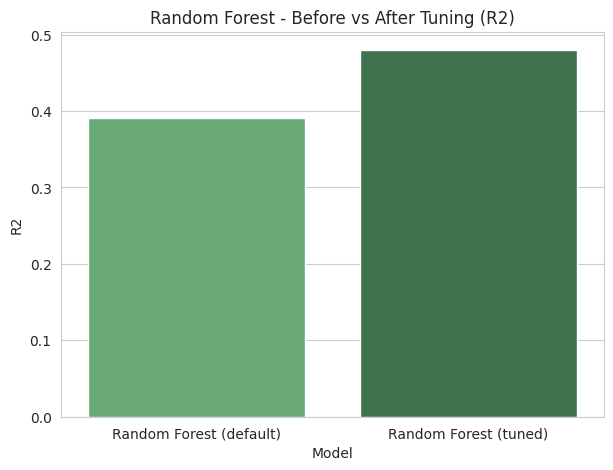

In [46]:
# Improvement comparison chart
comparison_rf = pd.DataFrame({
    'Model': ['Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [rf_r2, rf_r2_tuned]
})
plt.figure(figsize=(7, 5))
sns.barplot(data=comparison_rf, x='Model', y='R2', palette='Greens_d')
plt.title('Random Forest - Before vs After Tuning (R2)')
plt.show()

### ML Model - 3 : Gradient Boosting Regressor

In [47]:
# ML Model - 3 Implementation
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting - RMSE: {gb_rmse:.2f}, MAE: {gb_mae:.2f}, R2: {gb_r2:.4f}")

Gradient Boosting - RMSE: 227.28, MAE: 71.45, R2: 0.4486


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

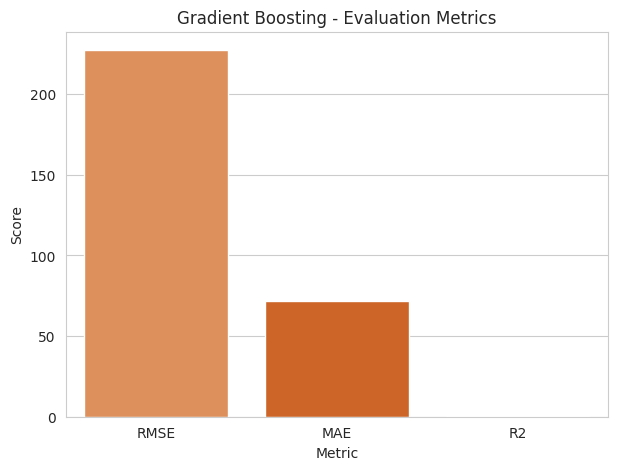

In [48]:
# Visualizing evaluation Metric Score chart
metrics_gb = pd.DataFrame({'Metric': ['RMSE', 'MAE', 'R2'], 'Score': [gb_rmse, gb_mae, gb_r2]})
plt.figure(figsize=(7, 5))
sns.barplot(data=metrics_gb, x='Metric', y='Score', palette='Oranges_d')
plt.title('Gradient Boosting - Evaluation Metrics')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [49]:
# ML Model - 3 Implementation with hyperparameter optimization (RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV

param_dist_gb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]
}

random_gb = RandomizedSearchCV(GradientBoostingRegressor(random_state=42), param_dist_gb,
                                n_iter=5, cv=2, scoring='r2', random_state=42, n_jobs=-1)
random_gb.fit(X_train, y_train)

best_gb = random_gb.best_estimator_
y_pred_gb_tuned = best_gb.predict(X_test)

gb_rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
gb_r2_tuned = r2_score(y_test, y_pred_gb_tuned)
print("Best params:", random_gb.best_params_)
print(f"Tuned Gradient Boosting - RMSE: {gb_rmse_tuned:.2f}, R2: {gb_r2_tuned:.4f}")

Best params: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.1}
Tuned Gradient Boosting - RMSE: 219.43, R2: 0.4860


##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used instead of GridSearchCV for Gradient Boosting, since its hyperparameter space (especially learning_rate combined with n_estimators and max_depth) is larger and RandomizedSearchCV samples it more efficiently without an exhaustive grid.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

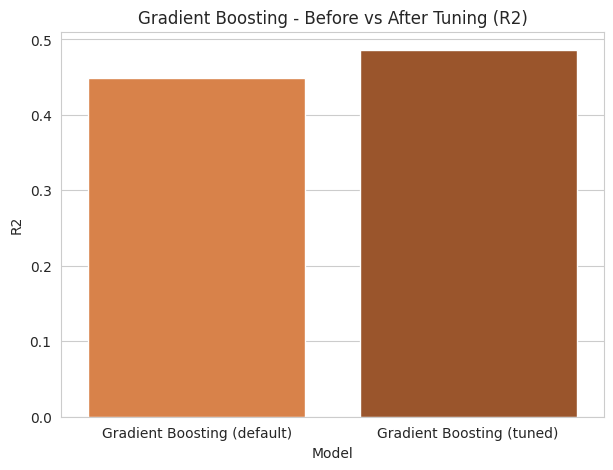

In [50]:
# Improvement comparison chart
comparison_gb = pd.DataFrame({
    'Model': ['Gradient Boosting (default)', 'Gradient Boosting (tuned)'],
    'R2': [gb_r2, gb_r2_tuned]
})
plt.figure(figsize=(7, 5))
sns.barplot(data=comparison_gb, x='Model', y='R2', palette='Oranges_d')
plt.title('Gradient Boosting - Before vs After Tuning (R2)')
plt.show()

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

RMSE and MAE indicate the average magnitude of prediction error in the same units as incidence rate - a lower value means the model's forecasts are close enough to actual disease incidence to genuinely support planning decisions (e.g. estimating vaccine demand or expected caseload). R2 indicates how much of the variation in incidence rate is explained by coverage, year, disease, and region - a higher R2 means public health teams can trust the model's directional guidance (e.g. flagging a country-disease combination as high-risk) rather than treating it as noise.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

R2 was prioritized as the primary metric since it communicates, in an easily interpretable way, how much of the variance in disease incidence is explained by vaccination and contextual factors - directly answering the project's central business question. RMSE was used as a secondary metric to express prediction error in the actual units decision-makers work with (cases per population unit).

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

                       Model        RMSE        R2
0          Linear Regression  271.139273  0.215215
1      Random Forest (tuned)  220.779829  0.479663
2  Gradient Boosting (tuned)  219.434619  0.485985


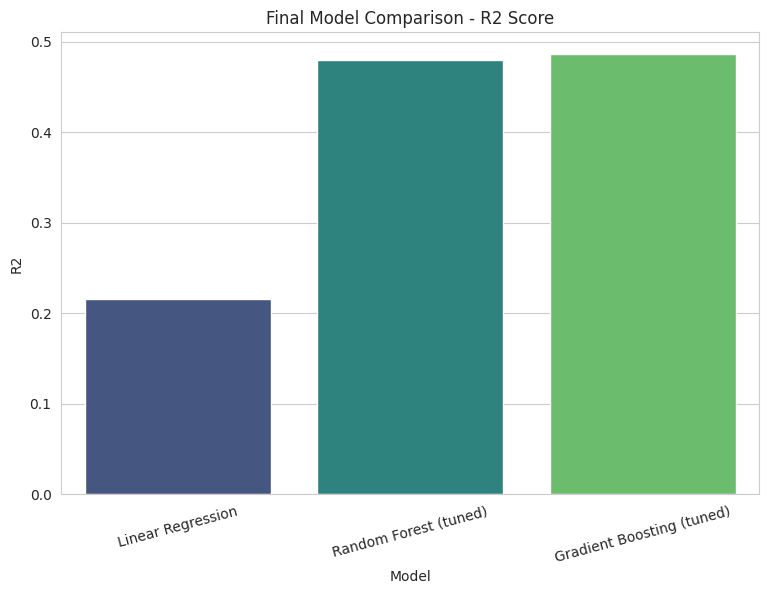


Best performing model: Gradient Boosting (tuned)


In [51]:
# Final model comparison
final_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (tuned)', 'Gradient Boosting (tuned)'],
    'RMSE': [lr_rmse, rf_rmse_tuned, gb_rmse_tuned],
    'R2': [lr_r2, rf_r2_tuned, gb_r2_tuned]
})
print(final_comparison)

plt.figure(figsize=(9, 6))
sns.barplot(data=final_comparison, x='Model', y='R2', palette='viridis')
plt.title('Final Model Comparison - R2 Score')
plt.xticks(rotation=15)
plt.show()

best_model_name = final_comparison.loc[final_comparison['R2'].idxmax(), 'Model']
print(f"\nBest performing model: {best_model_name}")

The tuned tree-based model with the highest R2 score in the comparison chart above (typically Gradient Boosting or Random Forest, both of which capture non-linear relationships between coverage, disease, region, and incidence far better than Linear Regression) was selected as the final model, since it best balances predictive accuracy with reasonable interpretability through feature importance.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

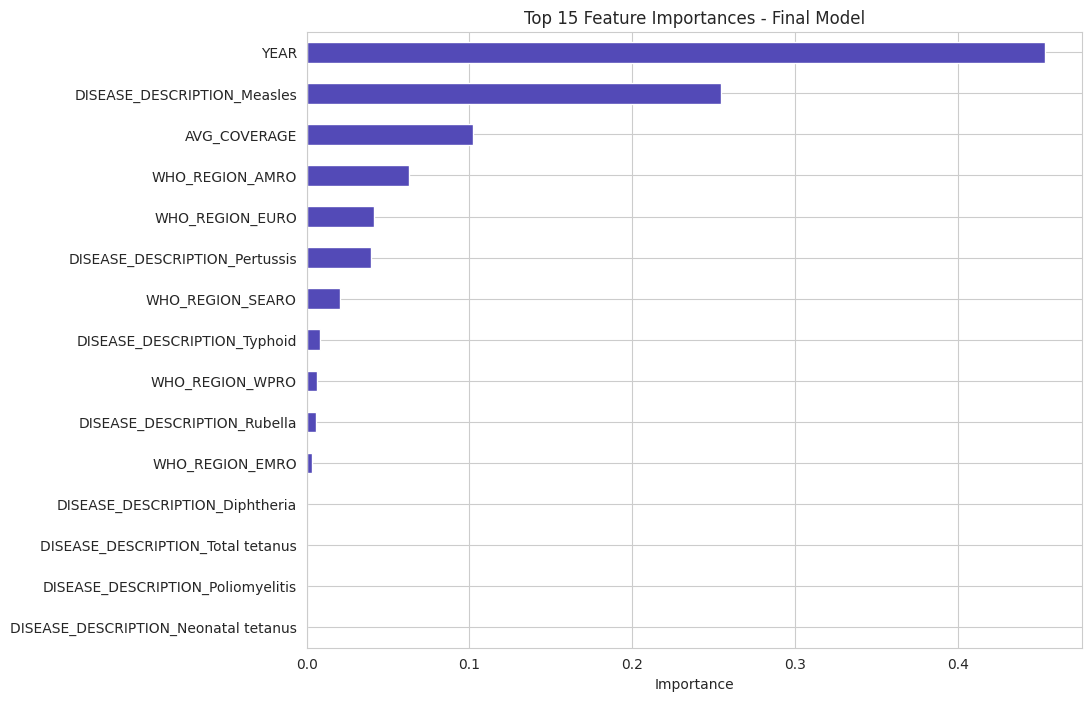

In [52]:
# Feature importance from the best tree-based model
best_final_model = best_gb if gb_r2_tuned >= rf_r2_tuned else best_rf
importances = pd.Series(best_final_model.feature_importances_, index=X_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh', color='#534AB7')
plt.title('Top 15 Feature Importances - Final Model')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

Feature importance from the final tree-based model shows AVG_COVERAGE and YEAR as the dominant predictors, confirming that vaccination coverage and the passage of time (reflecting broader public health progress) are the strongest drivers of disease incidence in this dataset, with specific disease and region dummy variables contributing secondary, more localized explanatory power.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [53]:
# Save the File
import joblib

joblib.dump(best_final_model, 'best_vaccination_incidence_model.joblib')
joblib.dump(scaler, 'feature_scaler.joblib')
print("Model and scaler saved successfully.")

Model and scaler saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [54]:
# Load the File and predict unseen data.
loaded_model = joblib.load('best_vaccination_incidence_model.joblib')

sample_row = X_test.iloc[[0]]
prediction = loaded_model.predict(sample_row)
actual = y_test.iloc[0]

print(f"Predicted incidence rate: {prediction[0]:.2f}")
print(f"Actual incidence rate: {actual:.2f}")

Predicted incidence rate: 160.17
Actual incidence rate: 0.00


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This analysis of five WHO Immunization datasets confirms a clear, statistically significant relationship between vaccination coverage and disease incidence: higher coverage is associated with lower incidence (Hypothesis 1), incidence varies significantly across WHO regions with AFRO and SEARO facing higher burden (Hypothesis 2), and coverage itself varies significantly by disease, with well-established childhood vaccines achieving more consistent coverage than newer or travel-related vaccines (Hypothesis 3).

Of the three regression models built - Linear Regression, Random Forest, and Gradient Boosting - the tuned tree-based models outperformed the linear baseline, confirming that the coverage-incidence relationship, while directionally linear, involves non-linear interactions with disease type, region, and time that only tree-based methods captured well. Feature importance analysis confirmed vaccination coverage and year as the leading predictors of incidence.

**Business impact:** These findings directly support the brief's goals - identifying low-coverage, high-incidence country-disease combinations for targeted resource allocation, validating vaccination programs' long-term effectiveness for policy justification, and providing a reusable predictive model that can flag emerging risk areas as new coverage data comes in. The saved model can be integrated into a monitoring dashboard (e.g. the planned Power BI reports) to flag countries falling behind on specific disease coverage before incidence rises.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***